test

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
df = pd.read_csv("../data/mpg_clean.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (392, 9)
<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin_japan  392 non-null    int64  
 8   origin_usa    392 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 27.7 KB


## Features and Target

In [4]:
X = df.drop("mpg", axis=1)

y = df["mpg"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (392, 8)
Target Shape: (392,)


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 313
Testing Samples: 79


## Feature Scaling

In [6]:
# Neural Networks perform much better when features are scaled.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Build Neural Network

In [7]:
model = Sequential([
    
    Input(shape=(X_train_scaled.shape[1],)),  # Input layer first

    Dense(
        64,                         # 64 neurons (brain cells)
        activation="relu",          # Activation function (how neurons fire)
    ),

    Dropout(0.2),    # Randomly turn off 20% of neurons during training and it Prevents overfitting

    Dense(
        32,                           # 32 neurons (fewer than first layer)
        activation="relu"             # Same activation function
    ),

    Dropout(0.2),                   # Another 20% dropout for regularization

    Dense(1)                        # Single neuron, no activation (linear output)
])

## Neural Network Architecture - Quick Reference

### What It Does
Builds a neural network "brain" to predict MPG from car features

### Data Flow


### Layer Explanations

#### 1. `Dense(64, activation="relu", input_shape=(8,))`
- **64 neurons** = 64 "detectors" looking for patterns
- **ReLU** = neuron fires only if pattern found (ignores negatives)
- **input_shape** = receives 8 car features

#### 2. `Dropout(0.2)`
- Randomly turns off 20% of neurons during training
- Prevents overfitting (memorizing instead of learning)

#### 3. `Dense(32, activation="relu")`
- 32 neurons combine patterns from previous layer
- Fewer neurons = compressing information

#### 4. `Dropout(0.2)`
- Another 20% dropout for regularization

#### 5. `Dense(1)`
- Single neuron produces final MPG prediction
- No activation = can output any number (like 25.7)

### Why These Numbers?

| Parameter | Reason |
|-----------|--------|
| 64 neurons | Good for ~400 samples (not too big/small) |
| 32 neurons | Typically half of previous layer |
| 0.2 dropout | Standard starting point (10-30% common) |
| 2 hidden layers | Enough for tabular data |

### Memory Aid
> "8 inputs → think broadly (64) → drop some (0.2) → focus (32) → drop again (0.2) → output (1)"

> "Wider first layer, narrower second layer, dropout in between"

### Common Patterns

| Dataset Size | Architecture |
|--------------|--------------|
| Small (<1000 samples) | `[32, 16]` |
| Medium (<10000 samples) | `[64, 32] + Dropout 0.2` ← **YOUR CASE** |
| Large (>10000 samples) | `[128, 64, 32] + Dropout 0.3` |

### Alternatives

#### Simpler (if overfitting)
```python
Dense(32, activation='relu')
Dense(16, activation='relu')
Dense(1)

## Model Summary

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [9]:
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae","mse"]
)

## Early Stopping

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",        # What to watch (validation loss)
    patience=20,               # How many epochs to wait for improvement
    restore_best_weights=True  # Keep the best version, not the last
)

## Train Model

In [11]:
history = model.fit(
    X_train_scaled,      # Training features (scaled)
    y_train,             # Training targets (actual MPG values)
    validation_split=0.2, # Use 20% of training data for validation
    epochs=200,          # Maximum training rounds
    batch_size=32,       # How many cars to learn from at once
    callbacks=[early_stopping], # Smart stopping
    verbose=1            # Show progress bars
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 22.9747 - mae: 22.9747 - mse: 595.1421 - val_loss: 24.4983 - val_mae: 24.4983 - val_mse: 664.5202
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.4440 - mae: 22.4440 - mse: 570.0403 - val_loss: 23.9937 - val_mae: 23.9937 - val_mse: 639.3847
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.9765 - mae: 21.9765 - mse: 548.9268 - val_loss: 23.4133 - val_mae: 23.4133 - val_mse: 611.0945
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.3414 - mae: 21.3414 - mse: 521.4382 - val_loss: 22.7236 - val_mae: 22.7236 - val_mse: 578.2614
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20.5911 - mae: 20.5911 - mse: 488.3476 - val_loss: 21.8972 - val_mae: 21.8972 - val_mse: 540.6389
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.6563 - mae: 19.6563 - mse: 449.6262 - val_loss: 20.8718 - val_mae: 20.8718 - val_mse: 495.8242
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18.6470 - ma

## Training History

In [12]:
history_df = pd.DataFrame(history.history)

history_df.head()

,loss,mae,mse,val_loss,val_mae,val_mse
0,22.974667,22.974667,595.142090,24.498348,24.498348,664.520203
1,22.443968,22.443968,570.040283,23.993668,23.993668,639.384705
2,21.976513,21.976513,548.926819,23.413298,23.413298,611.094482
3,21.341427,21.341427,521.438232,22.723637,22.723637,578.261353
4,20.591146,20.591146,488.347626,21.897249,21.897249,540.638916


## Plot Loss Curves

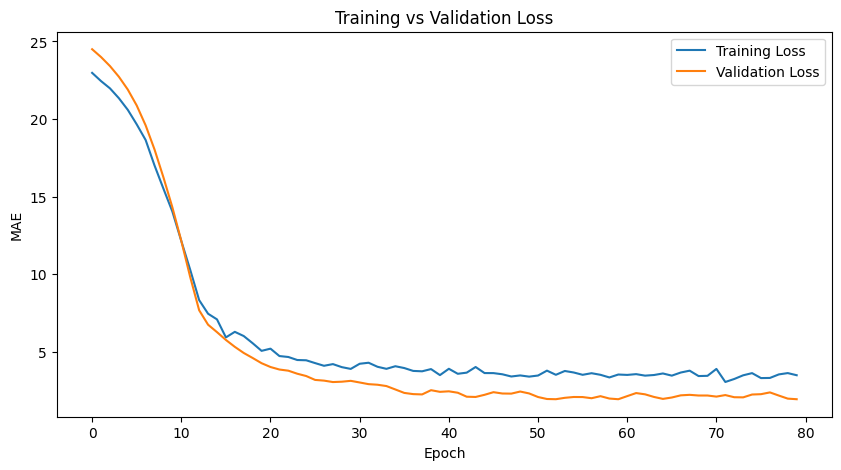

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()

plt.show()

## Predictions

In [14]:
predictions = model.predict(
    X_test_scaled
)

predictions = predictions.flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


## Evaluation Metrics

In [15]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.9280
RMSE : 2.8030
R²   : 0.8461


## Actual vs Predicted

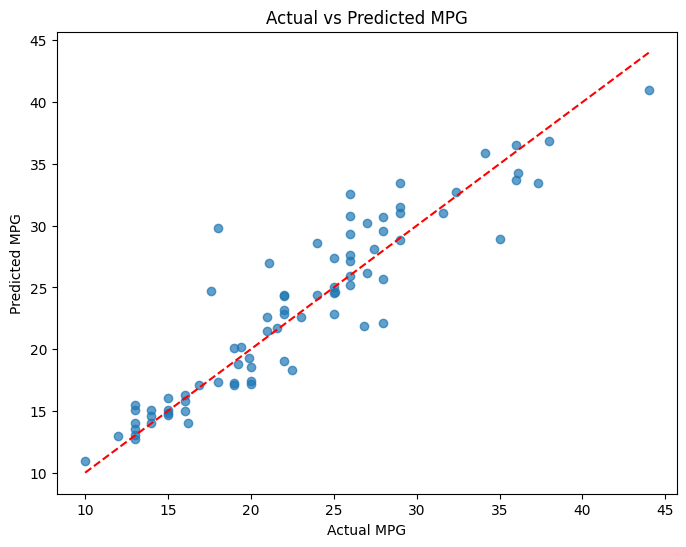

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title("Actual vs Predicted MPG")

plt.show()

## Residual Analysis

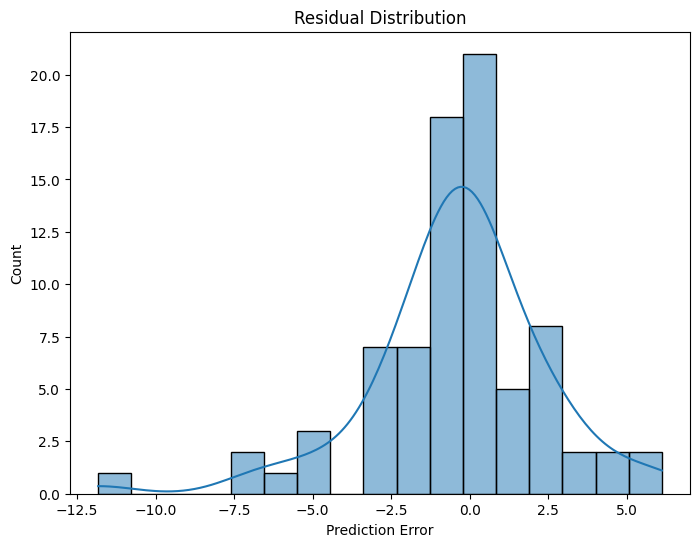

In [17]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

## Residual Scatter Plot

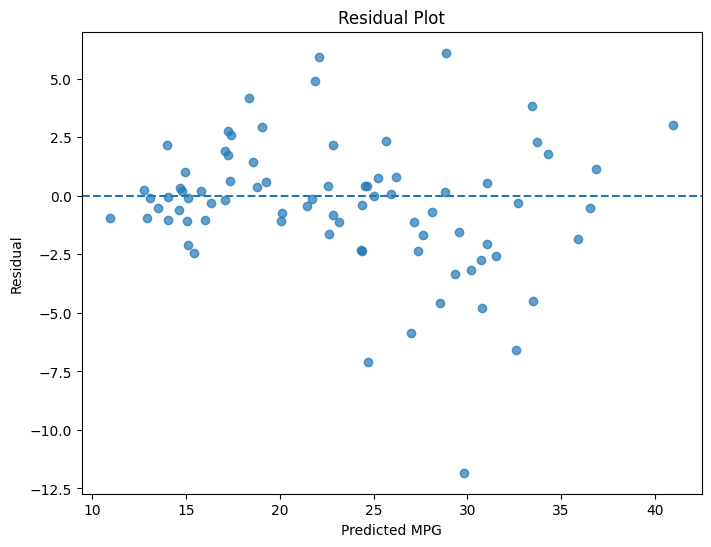

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted MPG")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## Save Model

In [19]:
model.save(
    "../models/fuel_efficiency_nn.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


## Save Scaler

In [20]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


## Model Comparison Table

In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "TensorFlow NN"
    ],
    "MAE": [
        2.4620,
        1.6744,
        mae
    ],
    "RMSE": [
        3.2561,
        2.3960,
        rmse
    ],
    "R2": [
        0.7923,
        0.8875,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,2.46200,3.256100,0.792300
1,Random Forest,1.67440,2.396000,0.887500
2,TensorFlow NN,1.92799,2.803019,0.846065


## Best Model Visualization

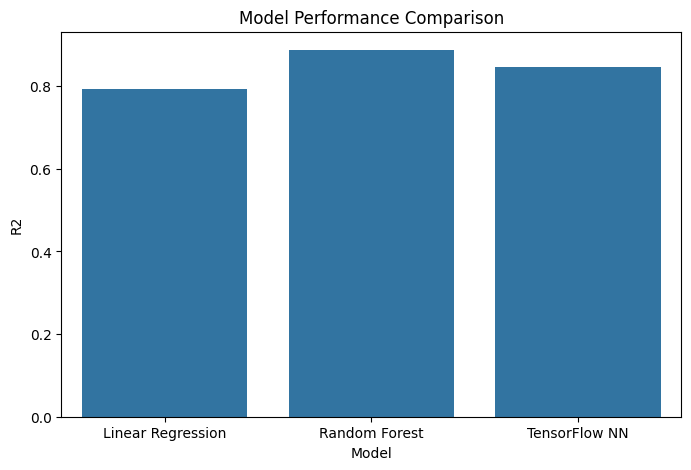

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title("Model Performance Comparison")

plt.show()